# Lesson 3 — Homework

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/djnzx/ida-practice-3d/blob/main/practice/3/3-homework.ipynb)

**Estimated time: 3-4 hours.**

## How to work through this

Each task gives a function signature and a docstring stating exactly what
to return. Replace `raise NotImplementedError` with your implementation;
the cell after it asserts the behaviour.

**A failing assert is information, not a grade.**

The written questions are marked and they carry the real learning
objective. Every one asks you to **run something both ways and explain
the difference** using numbers you produced. For each hyperparameter you
are asked about, say explicitly **which direction is underfitting, which
is overfitting, and what the metric does at each extreme**.

Every function you need is demonstrated in `3-practice.ipynb`, and each
task names the section.

## Before you submit

**Runtime → Restart and run all must complete without error** with every
assert passing. Then **File → Download → Download .ipynb**, rename the file to
`3-homework-results.ipynb`, and commit it to your fork under
`practice/3/`. Keep the outputs in the file; do not clear them.
The full procedure is in `practice/README.md` §8.

## 1. Setup

In [1]:
import sys
import time

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

SEED = 20250919
rng = np.random.default_rng(SEED)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 130)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (7.0, 4.5)
plt.rcParams["figure.dpi"] = 110

print("python", sys.version.split()[0], "| scikit-learn", sklearn.__version__)

python 3.13.15 | scikit-learn 1.6.1


In [2]:
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, KFold, GridSearchCV)
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score,
                             silhouette_score, adjusted_rand_score)

titanic = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/titanic.csv"
)
wine = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/wine.csv"
)
iris = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/iris.csv"
)
bikes = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/bike_sharing_hourly.csv"
)

print("titanic", titanic.shape, "| wine", wine.shape, "| iris", iris.shape, "| bikes", bikes.shape)

titanic (891, 12) | wine (178, 14) | iris (150, 6) | bikes (17379, 17)


In [5]:
# LOCAL ALTERNATIVE. Run EITHER this cell OR the one above, not both.
# Above reads over the network and is what Colab needs. This one reads
# the same files from your checkout, for the dev-env container. The
# data is identical; only the address differs.
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, KFold, GridSearchCV)
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score,
                             silhouette_score, adjusted_rand_score)

titanic = pd.read_csv("../datasets/titanic.csv")
wine = pd.read_csv("../datasets/wine.csv")
iris = pd.read_csv("../datasets/iris.csv")
bikes = pd.read_csv("../datasets/bike_sharing_hourly.csv")

print("titanic", titanic.shape, "| wine", wine.shape, "| iris", iris.shape, "| bikes", bikes.shape)

FileNotFoundError: [Errno 2] No such file or directory: '../datasets/titanic.csv'

## 2. Task 1 — Regression metrics from their definitions

Mechanical. Do not call scikit-learn's metric functions; build them from
the errors.

*see Practice 3 §4.2*

In [6]:
def regression_metrics(y_true, y_pred):
    """Return a dict with keys 'mse', 'rmse', 'mae', 'r2'.

        mse  = mean of the squared errors
        rmse = square root of mse
        mae  = mean of the absolute errors
        r2   = 1 - (sum of squared errors) / (sum of squared deviations
               of y_true from its own mean)

    Return Python/NumPy floats. Do not import from sklearn.metrics.
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    errors = y_true - y_pred

    mse = np.mean(errors ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(errors))

    ss_res = np.sum(errors ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)

    r2 = 1 - (ss_res / ss_tot)

    return {
        "mse": float(mse),
        "rmse": float(rmse),
        "mae": float(mae),
        "r2": float(r2)
    }

In [7]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

_truth = np.array([10.0, 20.0, 30.0, 40.0, 50.0])
_guess = np.array([12.0, 18.0, 33.0, 39.0, 54.0])
_m = regression_metrics(_truth, _guess)

assert set(_m) == {"mse", "rmse", "mae", "r2"}
assert np.isclose(_m["mse"], mean_squared_error(_truth, _guess)), f"mse wrong: {_m['mse']}"
assert np.isclose(_m["rmse"], np.sqrt(mean_squared_error(_truth, _guess)))
assert np.isclose(_m["mae"], mean_absolute_error(_truth, _guess)), f"mae wrong: {_m['mae']}"
assert np.isclose(_m["r2"], r2_score(_truth, _guess)), f"r2 wrong: {_m['r2']}"

# A perfect prediction: zero error, R^2 exactly 1.
_perfect = regression_metrics(_truth, _truth)
assert np.isclose(_perfect["mse"], 0.0) and np.isclose(_perfect["r2"], 1.0)

# Predicting the mean every time gives R^2 of exactly 0, by construction.
_mean_only = regression_metrics(_truth, np.full_like(_truth, _truth.mean()))
assert np.isclose(_mean_only["r2"], 0.0), \
    f"always predicting the mean must give R^2 = 0, you got {_mean_only['r2']}"

# RMSE >= MAE always, with equality only when every error has the same size.
_noisy = rng.normal(0, 5, 500)
_m2 = regression_metrics(_noisy, np.zeros(500))
assert _m2["rmse"] >= _m2["mae"]

print({k: round(v, 4) for k, v in _m.items()})
print("Task 1 passed.")

{'mse': 6.8, 'rmse': 2.6077, 'mae': 2.4, 'r2': 0.966}
Task 1 passed.


### Question 1 — reading the metrics

Fit a `LinearRegression` to the bicycle data using `temp`, `hum` and
`windspeed` to predict `cnt`, on a 75/25 split with `random_state=SEED`.
Report all four metrics on the test set with your `regression_metrics`.

**(a)** Explain what RMSE means **in bicycles** for this model. Then
explain why the MSE figure cannot be interpreted the same way.

**(b)** Compute the ratio RMSE / MAE. What does a ratio well above 1 tell
you about the distribution of the errors? Find the ten worst-predicted
hours and say what they have in common.

**(c)** Your R² is low. Add the one-hot encoded `hr` column and refit.
How much does R² improve? Explain, referring to Practice 2 §8.4, why hour
of day carries so much of the signal and why it had to be one-hot encoded
rather than used as an integer.

In [8]:
# Space for the code that supports your answer.
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np

# -------------------------------------------------
# (a) Basic model: temp, hum, windspeed
# -------------------------------------------------

features = ["temp", "hum", "windspeed"]

X = bikes[features]
y = bikes["cnt"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=SEED
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

metrics_basic = regression_metrics(y_test, y_pred)

print("=== BASIC MODEL ===")
for name, value in metrics_basic.items():
    print(f"{name}: {value:.4f}")

# RMSE / MAE ratio
ratio = metrics_basic["rmse"] / metrics_basic["mae"]

print("\nRMSE / MAE:", round(ratio, 4))


# -------------------------------------------------
# (b) Ten worst predictions
# -------------------------------------------------

test_results = bikes.loc[X_test.index].copy()

test_results["actual"] = y_test
test_results["predicted"] = y_pred
test_results["error"] = y_test - y_pred
test_results["abs_error"] = np.abs(test_results["error"])

worst10 = test_results.nlargest(10, "abs_error")

print("\n=== TEN WORST-PREDICTED HOURS ===")

cols = [
    "dteday", "hr", "workingday",
    "temp", "hum", "windspeed",
    "actual", "predicted", "abs_error"
]

print(worst10[cols].round(2))


# -------------------------------------------------
# (c) Add one-hot encoded hour
# -------------------------------------------------

X_hour = bikes[
    ["temp", "hum", "windspeed", "hr"]
].copy()

X_hour = pd.get_dummies(
    X_hour,
    columns=["hr"],
    drop_first=False
)

Xh_train, Xh_test, yh_train, yh_test = train_test_split(
    X_hour,
    y,
    test_size=0.25,
    random_state=SEED
)

model_hour = LinearRegression()
model_hour.fit(Xh_train, yh_train)

yh_pred = model_hour.predict(Xh_test)

metrics_hour = regression_metrics(yh_test, yh_pred)

print("\n=== MODEL WITH ONE-HOT HOUR ===")
for name, value in metrics_hour.items():
    print(f"{name}: {value:.4f}")

improvement = (
    metrics_hour["r2"] - metrics_basic["r2"]
)

print(
    "\nR2 improvement:",
    round(improvement, 4)
)

=== BASIC MODEL ===
mse: 25094.1254
rmse: 158.4113
mae: 118.9047
r2: 0.2511

RMSE / MAE: 1.3323

=== TEN WORST-PREDICTED HOURS ===
           dteday  hr  workingday   temp    hum  windspeed  actual  predicted  abs_error
15132  2012-09-27  17           1 0.6600 0.6900     0.3000     905   232.4200   672.5800
15276  2012-10-03  17           1 0.7000 0.6500     0.0000     917   254.7700   662.2300
15771  2012-10-24   8           1 0.5200 0.8300     0.1000     801   141.3300   659.6700
15099  2012-09-26   8           1 0.5600 0.7300     0.3000     838   185.2900   652.7100
15267  2012-10-03   8           1 0.6200 0.8800     0.1000     809   163.7200   645.2800
15756  2012-10-23  17           1 0.6800 0.4100     0.0000     938   313.5300   624.4700
11283  2012-04-20   8           1 0.4400 0.9400     0.0000     700    81.0900   618.9100
14220  2012-08-20  17           1 0.7000 0.5800     0.2800     893   276.9700   616.0300
15747  2012-10-23   8           1 0.4600 0.7200     0.0900     761  

**Your answer:**

(a) The basic linear regression model gives MSE = 25094.13, RMSE = 158.41, MAE = 118.90, and R² = 0.2511. An RMSE of about 158.4 means that the model's prediction errors are typically on the scale of roughly 158 bicycles, with larger errors receiving more weight because they are squared before averaging. MSE = 25094.13 cannot be interpreted directly as a number of bicycles because its units are bicycles squared; taking the square root returns the error measure to the original units.

(b) The RMSE/MAE ratio is 1.3323. Because RMSE penalizes large errors more strongly than MAE, a ratio noticeably above 1 indicates that the error distribution contains some relatively large errors rather than all errors being similar in size. The ten worst predictions have absolute errors of roughly 607–673 bicycles. All ten occur on working days, and they are concentrated at 08:00 and 17:00. These are the morning and evening commuting peaks, showing that a model using only temperature, humidity and wind speed cannot capture the strong hour-of-day demand pattern.

(c) After adding hour as a one-hot encoded feature, R² increases from 0.2511 to 0.6052, an improvement of 0.3541. This large increase shows that hour of day carries substantial information about bicycle demand because demand has a strong daily structure, especially the morning and evening commuting peaks on working days. Hour should be one-hot encoded rather than treated as an ordinary integer because its relationship with demand is not linear and time of day is cyclic: for example, 23:00 and 00:00 are adjacent in time despite their integer codes being far apart. One-hot encoding allows the regression model to learn a separate effect for each hour without imposing an artificial linear relationship between the hour number and demand.

## 3. Task 2 — Classification metrics from the confusion matrix

Mechanical. Again, build them by hand.

*see Practice 3 §9.2 and §9.3*

In [9]:
def binary_metrics(y_true, y_pred):
    """Return a dict of binary classification metrics computed from the
    four cells of the confusion matrix.

    Keys, exactly these seven:
        'tn', 'fp', 'fn', 'tp'   the four counts, as ints
        'precision'  TP / (TP + FP)
        'recall'     TP / (TP + FN)
        'f1'         harmonic mean of precision and recall

    The positive class is 1. If a denominator is zero, return 0.0 for
    that metric rather than raising.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    tn = int(np.sum((y_true == 0) & (y_pred == 0)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))
    tp = int(np.sum((y_true == 1) & (y_pred == 1)))

    precision = tp / (tp + fp) if (tp + fp) != 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) != 0 else 0.0

    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) != 0
        else 0.0
    )

    return {
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1)
    }

In [10]:
_y_true = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
_y_pred = np.array([0, 0, 0, 1, 1, 1, 1, 0, 0, 0])
_b = binary_metrics(_y_true, _y_pred)

assert set(_b) == {"tn", "fp", "fn", "tp", "precision", "recall", "f1"}
assert (_b["tn"], _b["fp"], _b["fn"], _b["tp"]) == (3, 1, 3, 3), \
    f"counts wrong: TN={_b['tn']} FP={_b['fp']} FN={_b['fn']} TP={_b['tp']}"
assert np.isclose(_b["precision"], 3 / 4)
assert np.isclose(_b["recall"], 3 / 6)
assert np.isclose(_b["f1"], 2 * 0.75 * 0.5 / 1.25)

# Must agree with sklearn's confusion_matrix, which orders cells the same way.
_sk_tn, _sk_fp, _sk_fn, _sk_tp = confusion_matrix(_y_true, _y_pred).ravel()
assert (_b["tn"], _b["fp"], _b["fn"], _b["tp"]) == (_sk_tn, _sk_fp, _sk_fn, _sk_tp)

# A model that never predicts the positive class: recall 0, no division error.
_never = binary_metrics(_y_true, np.zeros(10, dtype=int))
assert _never["recall"] == 0.0 and _never["precision"] == 0.0 and _never["f1"] == 0.0

print(_b)
print("Task 2 passed.")

{'tn': 3, 'fp': 1, 'fn': 3, 'tp': 3, 'precision': 0.75, 'recall': 0.5, 'f1': 0.6}
Task 2 passed.


## 4. Task 3 — The baseline you must state first

Mechanical.

*see Practice 3 §9.4*

In [11]:
def baseline_and_model(y_true, y_pred):
    """Compare a model against the majority-class baseline.

    The baseline predicts the most frequent class in `y_true` for every
    row. (Using y_true to find the majority class is a simplification for
    this exercise; in Practice 3 §15 the baseline is fitted on the
    training set, which is the correct procedure.)

    Return a dict with exactly these four keys:
        'majority_class'    the most frequent label in y_true, as an int
        'baseline_accuracy' accuracy of always predicting it
        'model_accuracy'    accuracy of y_pred
        'improvement'       model_accuracy - baseline_accuracy
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    # Find the majority class
    values, counts = np.unique(y_true, return_counts=True)
    majority_class = int(values[np.argmax(counts)])

    # Baseline: always predict the majority class
    baseline_pred = np.full_like(y_true, majority_class)

    baseline_accuracy = float(np.mean(baseline_pred == y_true))
    model_accuracy = float(np.mean(y_pred == y_true))

    improvement = model_accuracy - baseline_accuracy

    return {
        "majority_class": majority_class,
        "baseline_accuracy": baseline_accuracy,
        "model_accuracy": model_accuracy,
        "improvement": improvement
    }

In [12]:
_imbalanced = np.array([0] * 95 + [1] * 5)
_always_zero = np.zeros(100, dtype=int)
_r = baseline_and_model(_imbalanced, _always_zero)

assert _r["majority_class"] == 0
assert np.isclose(_r["baseline_accuracy"], 0.95)
assert np.isclose(_r["model_accuracy"], 0.95)
assert np.isclose(_r["improvement"], 0.0), \
    "a model that only predicts the majority class improves on the baseline by exactly 0"

_titanic_r = baseline_and_model(titanic["Survived"].values, np.zeros(len(titanic), dtype=int))
assert _titanic_r["majority_class"] == 0
assert np.isclose(_titanic_r["baseline_accuracy"], 0.6162, atol=1e-3), \
    f"Titanic's majority-class baseline is 0.6162, you got {_titanic_r['baseline_accuracy']}"

print(f"On a 95/5 split, a model with 95% accuracy has improved by "
      f"{_r['improvement']:.4f} over doing nothing.")
print("Task 3 passed.")

On a 95/5 split, a model with 95% accuracy has improved by 0.0000 over doing nothing.
Task 3 passed.


## 5. Task 4 — A leak-free pipeline

Applied. The scaler must be re-fitted inside every fold.

*see Practice 3 §6.3*

In [13]:
def compare_leak(X, y, cv):
    """Quantify the leak from scaling before cross-validating.

    Build two cross-validated accuracy estimates of an
    SVC(kernel='rbf', C=1.0, gamma='scale', random_state=SEED):

      'leaky'   scale X with a StandardScaler fitted on ALL of X, then
                cross-validate the bare SVC on the scaled array
      'clean'   cross-validate a Pipeline of StandardScaler then SVC,
                so the scaler is re-fitted on each fold's training rows

    Use the `cv` object passed in for both, and scoring='accuracy'.

    Return a dict with four keys:
        'leaky'           mean accuracy of the leaky procedure, a float
        'clean'           mean accuracy of the clean procedure, a float
        'difference'      leaky - clean
        'clean_estimator' the (unfitted) estimator object you passed to
                          cross_val_score for the clean path
    """
    # Leaky approach:
    # fit the scaler on ALL data before cross-validation
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    leaky_estimator = SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        random_state=SEED
    )

    leaky_scores = cross_val_score(
        leaky_estimator,
        X_scaled,
        y,
        cv=cv,
        scoring="accuracy"
    )

    # Clean approach:
    # scaler is fitted separately inside every CV fold
    clean_estimator = make_pipeline(
        StandardScaler(),
        SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
            random_state=SEED
        )
    )

    clean_scores = cross_val_score(
        clean_estimator,
        X,
        y,
        cv=cv,
        scoring="accuracy"
    )

    leaky = float(np.mean(leaky_scores))
    clean = float(np.mean(clean_scores))

    return {
        "leaky": leaky,
        "clean": clean,
        "difference": leaky - clean,
        "clean_estimator": clean_estimator
    }

In [14]:
_wine_features = [c for c in wine.columns if c != "target"]
_X_wine = wine[_wine_features].values
_y_wine = wine["target"].values
_cv = StratifiedKFold(5, shuffle=True, random_state=SEED)

_leak = compare_leak(_X_wine, _y_wine, _cv)

assert set(_leak) == {"leaky", "clean", "difference", "clean_estimator"}
assert 0.9 < _leak["clean"] < 1.0, f"the clean score looks wrong: {_leak['clean']}"
assert np.isclose(_leak["difference"], _leak["leaky"] - _leak["clean"])

# The clean path must go through a Pipeline: that is the whole point, and it
# is checkable directly rather than through the score.
_estimator = _leak["clean_estimator"]
assert isinstance(_estimator, Pipeline), \
    f"the clean path must use a Pipeline, you passed a {type(_estimator).__name__}"
_step_types = [type(step).__name__ for _, step in _estimator.steps]
assert _step_types == ["StandardScaler", "SVC"], \
    f"expected StandardScaler then SVC, got {_step_types}"
# cross_val_score clones its estimator, so the object you passed in should
# still be unfitted. A fitted SVC carries a support_ attribute (Practice 3
# section 2: a trailing underscore means fit set it).
assert not hasattr(_estimator.named_steps["svc"], "support_"), \
    "return the estimator you passed to cross_val_score, not one you fitted yourself"

print(f"wine  leaky {_leak['leaky']:.4f}  clean {_leak['clean']:.4f}  "
      f"difference {_leak['difference']:+.4f}")
print("The two agree to four decimals here. Question 2(c) asks why, and when they would not.")
print("Task 4 passed.")

wine  leaky 0.9833  clean 0.9833  difference +0.0000
The two agree to four decimals here. Question 2(c) asks why, and when they would not.
Task 4 passed.


### Question 2 — folds and leakage

**(a)** Re-run `compare_leak` on the wine data with `cv` set to
`StratifiedKFold(k)` for k = 2, 5, 10 and `len(y)` (leave-one-out).
Tabulate the clean score and the leak at each. **Which direction does the
number of folds push the leak, and why?** Think about how much of the
data each fold's scaler sees.

**(b)** More folds means each model trains on more data and you fit more
models. State the trade-off in terms of bias, variance of the estimate,
and compute cost. Why is 5 or 10 the usual choice rather than
leave-one-out?

**(c)** Practice 3 §6.3 showed the leak reaching 27 percentage points with
a feature selector on pure noise, and essentially zero with a scaler on
wine. State the general rule that predicts which case you are in.

In [15]:
from sklearn.model_selection import LeaveOneOut

X_wine = wine.drop(columns=["target"]).values
y_wine = wine["target"].values

results = []

# k = 2, 5, 10
for k in [2, 5, 10]:
    cv = StratifiedKFold(
        n_splits=k,
        shuffle=True,
        random_state=SEED
    )

    result = compare_leak(X_wine, y_wine, cv)

    results.append({
        "folds": k,
        "clean": result["clean"],
        "leak": result["difference"]
    })

# Leave-one-out
cv_loo = LeaveOneOut()

result_loo = compare_leak(
    X_wine,
    y_wine,
    cv_loo
)

results.append({
    "folds": len(y_wine),
    "clean": result_loo["clean"],
    "leak": result_loo["difference"]
})

results_df = pd.DataFrame(results)

print(results_df.to_string(index=False))

 folds  clean    leak
     2 0.9775 -0.0056
     5 0.9833  0.0000
    10 0.9833  0.0000
   178 0.9831  0.0000


**Your answer:**

(a) With 2 folds, the clean accuracy is 0.9775 and the measured leak (leaky - clean) is -0.0056. With 5 folds the clean accuracy is 0.9833 and the leak is 0.0000; with 10 folds it is also 0.9833 with a leak of 0.0000; and with leave-one-out (178 folds) the clean accuracy is 0.9831 with essentially zero leak. In this dataset the leakage from scaling is therefore extremely small and disappears at the displayed precision as the number of folds increases. With more folds, each training fold contains a larger fraction of the full dataset, so the scaler fitted inside the fold becomes increasingly similar to a scaler fitted on all observations. Thus the difference between the leaky and clean procedures tends to shrink.

(b) Increasing the number of folds means that each model is trained on more observations, which generally reduces the training-set-size bias of the cross-validation estimate. However, the individual validation sets become smaller, so the fold scores can be more variable, and many more models must be fitted. Leave-one-out is the extreme case: it trains on almost the entire dataset each time but requires 178 model fits and can have a high-variance estimate because each test fold contains only one observation. Five or ten folds are usually a better practical compromise between bias, variance and computational cost.

(c) The size of leakage depends on how strongly the preprocessing step learns information from the data and how much that learned information can adapt to the validation observations. StandardScaler only estimates simple feature means and standard deviations, so on a stable dataset such as wine, fitting it on all observations instead of only the training fold changes little; here the measured leakage is essentially zero for 5, 10 and leave-one-out folds. A feature-selection procedure is much more dangerous because it can search many features and select those that happen, by chance, to correlate with the target, even when the features are pure noise. The general rule is that every data-dependent preprocessing or selection step must be fitted inside each training fold, and the more adaptive or target-informed the step is, the greater the potential optimism from leakage.

## 6. Task 5 — The bias-variance curve

Applied.

*see Practice 3 §7.3*

In [16]:
def degree_sweep(x, y, degrees, cv):
    """Fit a polynomial regression at each degree and record both errors.

    For each degree d in `degrees`, build
    make_pipeline(PolynomialFeatures(degree=d), LinearRegression()).

        train_mse  fit on ALL of (x, y), then the MSE of its predictions
                   on that same data
        cv_mse     the mean of -cross_val_score(..., cv=cv,
                   scoring='neg_mean_squared_error')

    `x` is 1-D; reshape it for scikit-learn (Practice 1 §3.5).

    Return a DataFrame indexed by degree with columns 'train_mse' and
    'cv_mse', in that order.
    """
    x = np.asarray(x).reshape(-1, 1)
    y = np.asarray(y)

    results = []

    for d in degrees:
        model = make_pipeline(
            PolynomialFeatures(degree=d),
            LinearRegression()
        )

        # Fit on all data and calculate training MSE
        model.fit(x, y)
        y_pred = model.predict(x)
        train_mse = np.mean((y - y_pred) ** 2)

        # Cross-validation MSE
        scores = cross_val_score(
            model,
            x,
            y,
            cv=cv,
            scoring="neg_mean_squared_error"
        )

        cv_mse = -np.mean(scores)

        results.append({
            "degree": d,
            "train_mse": float(train_mse),
            "cv_mse": float(cv_mse)
        })

    result = pd.DataFrame(results).set_index("degree")

    return result[["train_mse", "cv_mse"]]

In [17]:
_poly_rng = np.random.default_rng(SEED)
_x_poly = _poly_rng.uniform(-3, 3, 50)
_y_poly = (_x_poly ** 4 - 3 * _x_poly ** 2 + _x_poly + 5) + _poly_rng.normal(0, 12.0, 50)

_sweep = degree_sweep(_x_poly, _y_poly, range(1, 16), KFold(5, shuffle=True, random_state=SEED))

assert list(_sweep.columns) == ["train_mse", "cv_mse"]
assert len(_sweep) == 15

# Training error must fall (weakly) as the model gains flexibility.
_train = _sweep["train_mse"].values
assert np.all(np.diff(_train) < 1e-6), \
    "training MSE must be non-increasing in the degree; a degree-d model can do anything a degree-(d-1) model can"

# Validation error must NOT be monotone: it has a minimum and then rises.
assert _sweep["cv_mse"].idxmin() < 15, "validation error should not be minimised at the highest degree"
assert _sweep.loc[15, "cv_mse"] > _sweep["cv_mse"].min() * 10, \
    "a degree-15 polynomial on 50 noisy points should overfit badly"
assert _sweep.loc[1, "cv_mse"] > _sweep["cv_mse"].min() * 2, \
    "a straight line should underfit a quartic badly"

print(_sweep.round(2).to_string())
print(f"\nbest degree by cross-validation: {_sweep['cv_mse'].idxmin()}")
print("Task 5 passed.")

        train_mse      cv_mse
degree                       
1        397.8800    468.4700
2        146.8600    165.9000
3        144.4100    168.8300
4         82.1600    111.8500
5         81.3900    120.0800
6         81.1400    128.5300
7         81.0700    157.3500
8         73.3200    113.4500
9         70.4200    115.2500
10        69.2800    118.8700
11        68.6700    171.4900
12        68.4400  1,699.0900
13        68.4400 19,405.7200
14        66.2600 91,266.7500
15        65.9500 28,992.7500

best degree by cross-validation: 4
Task 5 passed.


### Question 3 — polynomial degree

Plot both columns of your sweep on one axes with a log y scale.

**(a)** Identify the underfitting region and the overfitting region by
degree. For each, say what the **training** error is doing and what the
**validation** error is doing, and explain why the gap between them is
the diagnostic rather than either curve alone.

**(b)** At the extremes: what does training MSE tend to as the degree
approaches the number of data points, and why? What does validation MSE
do?

**(c)** Re-run the sweep with 500 points instead of 50, same noise. Which
degree wins now, and how far does the overfitting region move? State the
general relationship between the amount of data and the model complexity
you can afford.

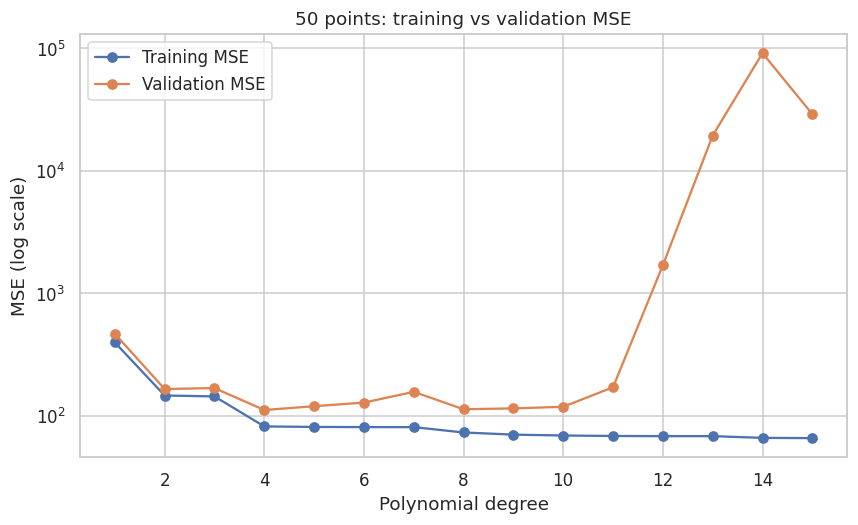

Best degree for 50 points: 4

500-point results:
        train_mse   cv_mse
degree                    
1        339.2000 341.5000
2        176.1400 178.2000
3        176.1300 179.7500
4        137.2900 140.5000
5        136.8800 140.6700
6        136.5100 141.0200
7        136.2600 141.2000
8        136.1500 143.0700
9        136.0600 143.1600
10       135.6100 143.7200
11       135.4800 144.7600
12       135.4600 148.3100
13       135.4100 158.6400
14       135.4100 184.2100
15       134.8000 168.0900

Best degree for 500 points: 4


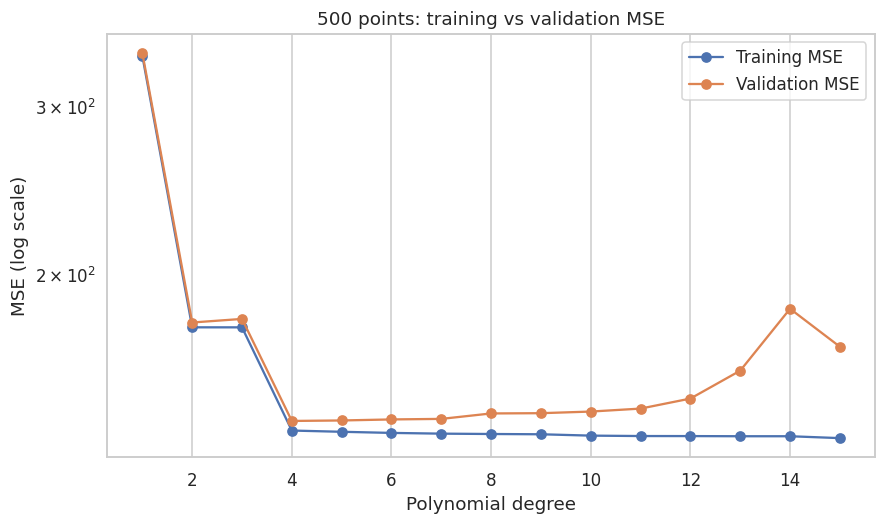

In [18]:
# Space for the code that supports your answer.
# ----- Original 50-point sweep -----

plt.figure(figsize=(9, 5))

plt.plot(
    _sweep.index,
    _sweep["train_mse"],
    marker="o",
    label="Training MSE"
)

plt.plot(
    _sweep.index,
    _sweep["cv_mse"],
    marker="o",
    label="Validation MSE"
)

plt.yscale("log")
plt.xlabel("Polynomial degree")
plt.ylabel("MSE (log scale)")
plt.title("50 points: training vs validation MSE")
plt.legend()
plt.grid(True)
plt.show()

print("Best degree for 50 points:",
      _sweep["cv_mse"].idxmin())


# ----- Repeat with 500 points and the same noise -----

_poly_rng_500 = np.random.default_rng(SEED)

_x_poly_500 = _poly_rng_500.uniform(-3, 3, 500)

_y_poly_500 = (
    _x_poly_500 ** 4
    - 3 * _x_poly_500 ** 2
    + _x_poly_500
    + 5
    + _poly_rng_500.normal(0, 12.0, 500)
)

_sweep_500 = degree_sweep(
    _x_poly_500,
    _y_poly_500,
    range(1, 16),
    KFold(5, shuffle=True, random_state=SEED)
)

print("\n500-point results:")
print(_sweep_500.round(2).to_string())

print(
    "\nBest degree for 500 points:",
    _sweep_500["cv_mse"].idxmin()
)


# Plot 500-point sweep

plt.figure(figsize=(9, 5))

plt.plot(
    _sweep_500.index,
    _sweep_500["train_mse"],
    marker="o",
    label="Training MSE"
)

plt.plot(
    _sweep_500.index,
    _sweep_500["cv_mse"],
    marker="o",
    label="Validation MSE"
)

plt.yscale("log")
plt.xlabel("Polynomial degree")
plt.ylabel("MSE (log scale)")
plt.title("500 points: training vs validation MSE")
plt.legend()
plt.grid(True)
plt.show()

**Your answer:**

(a) For the 50-point dataset, the underfitting region is mainly at degrees 1–3. At degree 1 both training MSE (397.88) and validation MSE (468.47) are high, meaning that the model is too simple to represent the underlying relationship. The validation error reaches its minimum at degree 4 (111.85), while the training MSE is 82.16. At higher degrees the training error continues to decrease, but the validation error eventually increases dramatically. Strong overfitting is especially visible from about degree 11–12 onward: the training MSE remains around 68–69 while validation MSE rises from 171.49 at degree 11 to 1,699.09 at degree 12 and much higher afterwards. The growing gap between training and validation error is diagnostic of overfitting because low training error alone only shows that the model can fit the observed data; it does not show that it generalises to unseen data.

(b) As the polynomial degree approaches the number of data points, a sufficiently flexible polynomial can interpolate the training observations, so training MSE can tend toward zero. However, this includes fitting random noise rather than only the underlying relationship. Consequently, validation MSE can become extremely large because the fitted polynomial behaves unstably on observations that were not used for fitting. Thus, at the high-complexity extreme, training error can approach zero while validation error increases sharply.

(c) With 500 points, degree 4 is still the best model. Its training MSE is 137.29 and its validation MSE is 140.50. However, the overfitting region moves much farther to the right and becomes much less severe: even degree 15 has a validation MSE of only 168.09, compared with the enormous validation errors produced by high degrees with only 50 points. More data therefore allows a model to support greater complexity before variance and overfitting dominate. In general, increasing the amount of data reduces the variance of flexible models and permits greater model complexity, although unnecessary complexity still does not improve generalisation.

## 7. Task 6 — Tune a tree honestly

Applied.

*see Practice 3 §8.3 and §6.4*

In [19]:
def tune_tree(X, y, cv, depths=(1, 2, 3, 4, 5, 6, 8, 10, None), criteria=("gini", "entropy")):
    """Grid-search a DecisionTreeClassifier over max_depth and criterion.

    Use GridSearchCV with the given `cv`, scoring='accuracy', refit=True,
    and DecisionTreeClassifier(random_state=SEED).

    Return a dict with exactly these four keys:
        'best_depth'      the chosen max_depth (may be None)
        'best_criterion'  the chosen criterion, a string
        'best_cv_score'   the best cross-validated accuracy, a float
        'search'          the fitted GridSearchCV object
    """
    param_grid = {
        "max_depth": depths,
        "criterion": criteria
    }

    tree = DecisionTreeClassifier(random_state=SEED)

    search = GridSearchCV(
        estimator=tree,
        param_grid=param_grid,
        cv=cv,
        scoring="accuracy",
        refit=True
    )

    search.fit(X, y)

    return {
        "best_depth": search.best_params_["max_depth"],
        "best_criterion": search.best_params_["criterion"],
        "best_cv_score": float(search.best_score_),
        "search": search
    }

In [20]:
_X_iris = iris.drop(columns=["Id", "Species"]).values
_y_iris = iris["Species"].values
_iris_cv = StratifiedKFold(5, shuffle=True, random_state=SEED)

_tuned = tune_tree(_X_iris, _y_iris, _iris_cv)

assert set(_tuned) == {"best_depth", "best_criterion", "best_cv_score", "search"}
assert _tuned["best_criterion"] in ("gini", "entropy")
assert 0.9 < _tuned["best_cv_score"] <= 1.0, f"CV score looks wrong: {_tuned['best_cv_score']}"
assert len(_tuned["search"].cv_results_["params"]) == 18, \
    "9 depths x 2 criteria = 18 combinations"

# A depth-1 tree cannot separate three classes: it has only two leaves.
_depth1 = cross_val_score(DecisionTreeClassifier(max_depth=1, random_state=SEED),
                          _X_iris, _y_iris, cv=_iris_cv).mean()
assert _depth1 < 0.75, f"a two-leaf tree should not classify three classes well, got {_depth1:.4f}"
assert _tuned["best_cv_score"] > _depth1, "tuning should beat the depth-1 stump"

# The chosen tree must not be the fully grown one if a shallower one ties it.
_full = cross_val_score(DecisionTreeClassifier(random_state=SEED), _X_iris, _y_iris, cv=_iris_cv).mean()
print(f"best: max_depth={_tuned['best_depth']}, criterion={_tuned['best_criterion']}, "
      f"CV {_tuned['best_cv_score']:.4f}")
print(f"depth-1 stump CV {_depth1:.4f}   fully grown tree CV {_full:.4f}")
print("Task 6 passed.")

best: max_depth=4, criterion=gini, CV 0.9333
depth-1 stump CV 0.6667   fully grown tree CV 0.9333
Task 6 passed.


### Question 4 — tree hyperparameters

**(a)** Using `_tuned['search'].cv_results_`, tabulate the CV score at
every `max_depth` for both criteria. **Which direction is underfitting
and which is overfitting?** Give the depth at which each begins for this
data.

**(b)** `gini` and `criterion='entropy'` gave nearly the same answer.
Explain what each measures and why they rarely disagree. Construct or
describe a situation in which they might.

**(c)** Fit a tree with `max_depth=None` and report its **training**
accuracy. Explain in one sentence why that number is uninformative, and
name the other hyperparameter from Practice 3 §8.3 that limits the same
behaviour from a different direction.

=== CV ACCURACY BY DEPTH AND CRITERION ===
param_criterion  entropy   gini
param_max_depth                
NaN               0.9333 0.9333
1.0000            0.6667 0.6667
2.0000            0.9200 0.9200
3.0000            0.9200 0.9200
4.0000            0.9333 0.9333
5.0000            0.9333 0.9333
6.0000            0.9333 0.9333
8.0000            0.9333 0.9333
10.0000           0.9333 0.9333

Best parameters:
Best depth: 4
Best criterion: gini
Best CV score: 0.9333

=== UNRESTRICTED TREE ===
Training accuracy: 1.0


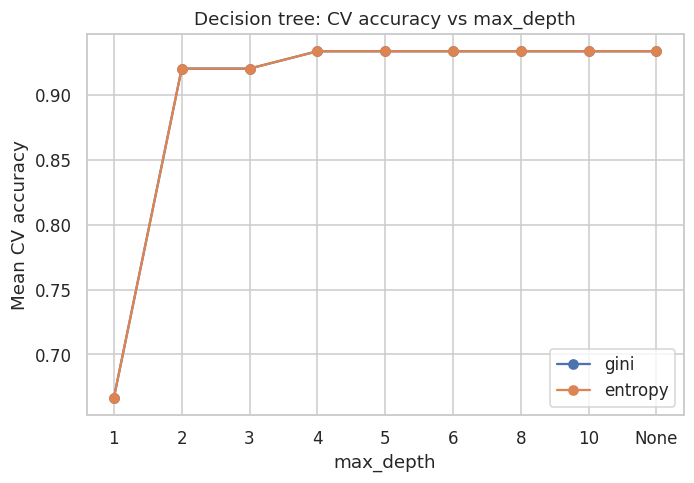

In [21]:
# Space for the code that supports your answer.
# Extract GridSearchCV results
cv_results = pd.DataFrame(_tuned["search"].cv_results_)

# Table: CV accuracy for every depth and criterion
table = cv_results.pivot(
    index="param_max_depth",
    columns="param_criterion",
    values="mean_test_score"
)

print("=== CV ACCURACY BY DEPTH AND CRITERION ===")
print(table.round(4))

print("\nBest parameters:")
print("Best depth:", _tuned["best_depth"])
print("Best criterion:", _tuned["best_criterion"])
print("Best CV score:", round(_tuned["best_cv_score"], 4))


# Fit an unrestricted tree for part (c)
tree_none = DecisionTreeClassifier(
    max_depth=None,
    random_state=SEED
)

tree_none.fit(X_wine, y_wine)

train_accuracy = tree_none.score(X_wine, y_wine)

print("\n=== UNRESTRICTED TREE ===")
print("Training accuracy:", round(train_accuracy, 4))


# Plot CV accuracy
plot_results = cv_results.copy()

# Convert None to a readable label
plot_results["depth_label"] = (
    plot_results["param_max_depth"]
    .astype(str)
)

for criterion in ["gini", "entropy"]:
    subset = plot_results[
        plot_results["param_criterion"] == criterion
    ]

    plt.plot(
        range(len(subset)),
        subset["mean_test_score"],
        marker="o",
        label=criterion
    )

plt.xticks(
    range(len(subset)),
    subset["depth_label"]
)

plt.xlabel("max_depth")
plt.ylabel("Mean CV accuracy")
plt.title("Decision tree: CV accuracy vs max_depth")
plt.legend()
plt.grid(True)
plt.show()

**Your answer:**

(a) The shallow tree underfits: at max_depth=1 the CV accuracy is only 0.6667, while at depth 2 it rises to 0.9200. Therefore the clearest underfitting region is depth 1. The best CV accuracy is 0.9333, first reached at max_depth=4, and it remains approximately the same for larger depths in this dataset. Thus there is no strong decline in CV accuracy indicating severe overfitting within the tested grid, although depths beyond 4 add complexity without improving validation performance. Both gini and entropy give almost identical CV results.

(b) Gini impurity measures how often a randomly labelled observation would be misclassified according to the class proportions in a node, while entropy measures the uncertainty or disorder of the class distribution using logarithms. Both favour splits that make child nodes purer, so they usually rank candidate splits similarly and therefore often produce very similar trees. They can disagree when two candidate splits produce very similar improvements but have different class distributions, causing the two impurity measures to rank those splits differently.

(c) With max_depth=None, the training accuracy is 1.0000. This number is not informative about generalisation because an unrestricted decision tree can keep splitting until it memorises the training observations, producing perfect training accuracy while potentially overfitting. Another hyperparameter that limits this behaviour from a different direction is min_samples_leaf: instead of directly limiting tree depth, it requires each leaf to contain a minimum number of training observations.

## 8. Task 7 — Choose k without touching the test set

Applied. This is the procedure from Practice 3 §10.4, implemented.

*see Practice 3 §10.3 and §10.4*

In [22]:
def honest_k_selection(X_train, y_train, X_test, y_test, k_values, cv):
    """Choose k by cross-validation on the training set, then measure once.

    For each k in `k_values`, cross-validate
    make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    on the TRAINING data only, using `cv`.

    Choose the k with the highest mean CV accuracy (the smallest such k if
    several tie). Refit that pipeline on all the training data and score
    it once on the test set.

    Also record, for comparison, the k that would have been chosen by
    scoring each k directly on the TEST set, and that k's test score.

    Return a dict with exactly these five keys:
        'cv_scores'         a 1-D array of mean CV accuracy, one per k
        'best_k_cv'         the k chosen by cross-validation
        'test_accuracy'     the honest test accuracy of that k
        'best_k_peeking'    the k that maximises test accuracy
        'peeking_accuracy'  that k's test accuracy (an optimistic number)
    """
    cv_scores = []
    test_scores = []

    # Evaluate every k
    for k in k_values:
        model = make_pipeline(
            StandardScaler(),
            KNeighborsClassifier(n_neighbors=k)
        )

        # Cross-validation ONLY on training data
        scores = cross_val_score(
            model,
            X_train,
            y_train,
            cv=cv,
            scoring="accuracy"
        )

        cv_scores.append(scores.mean())

        # Test-set score, recorded only for comparison
        model.fit(X_train, y_train)
        test_scores.append(model.score(X_test, y_test))

    cv_scores = np.asarray(cv_scores)
    test_scores = np.asarray(test_scores)

    # Honest choice: highest CV accuracy.
    # np.argmax returns the first maximum, so ties choose smallest k
    best_cv_idx = np.argmax(cv_scores)
    best_k_cv = k_values[best_cv_idx]

    # Refit the honestly selected model on all training data
    best_model = make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=best_k_cv)
    )

    best_model.fit(X_train, y_train)
    test_accuracy = best_model.score(X_test, y_test)

    # Dishonest choice: choose k directly from test accuracy
    best_test_idx = np.argmax(test_scores)
    best_k_peeking = k_values[best_test_idx]
    peeking_accuracy = test_scores[best_test_idx]

    return {
        "cv_scores": cv_scores,
        "best_k_cv": best_k_cv,
        "test_accuracy": float(test_accuracy),
        "best_k_peeking": best_k_peeking,
        "peeking_accuracy": float(peeking_accuracy)
    }

In [23]:
_t = titanic.copy()
_t["Age"] = _t["Age"].fillna(_t.groupby(["Pclass", "Sex"])["Age"].transform("median"))
_t["Sex"] = (_t["Sex"] == "female").astype(int)
_X_knn = _t[["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare"]].values
_y_knn = _t["Survived"].values

_Xk_tr, _Xk_te, _yk_tr, _yk_te = train_test_split(
    _X_knn, _y_knn, test_size=0.25, random_state=SEED, stratify=_y_knn
)
_k_cv = StratifiedKFold(5, shuffle=True, random_state=SEED)
_sel = honest_k_selection(_Xk_tr, _yk_tr, _Xk_te, _yk_te, range(1, 31), _k_cv)

assert set(_sel) == {"cv_scores", "best_k_cv", "test_accuracy",
                     "best_k_peeking", "peeking_accuracy"}
assert len(_sel["cv_scores"]) == 30
assert 1 <= _sel["best_k_cv"] <= 30

# The k chosen by CV must be the argmax OF THE CV SCORES, not of the test scores.
assert _sel["best_k_cv"] == list(range(1, 31))[int(np.argmax(_sel["cv_scores"]))], \
    "best_k_cv must maximise the cross-validated score, not the test score"

# Peeking at the test set can never look worse than the honest procedure:
# it is the maximum over the same set of numbers.
assert _sel["peeking_accuracy"] >= _sel["test_accuracy"] - 1e-12, \
    "selecting on the test set cannot produce a lower test score than any single choice"

print(f"k by cross-validation : {_sel['best_k_cv']:2}  ->  honest test accuracy "
      f"{_sel['test_accuracy']:.4f}")
print(f"k by peeking at test  : {_sel['best_k_peeking']:2}  ->  optimistic accuracy "
      f"{_sel['peeking_accuracy']:.4f}")
print(f"the optimism is {_sel['peeking_accuracy'] - _sel['test_accuracy']:+.4f}")
print("Task 7 passed.")

k by cross-validation : 18  ->  honest test accuracy 0.8206
k by peeking at test  : 25  ->  optimistic accuracy 0.8520
the optimism is +0.0314
Task 7 passed.


### Question 5 — k, and the one-use rule

**(a)** Plot your `cv_scores` against k. **Which end is underfitting and
which is overfitting?** Describe what the model does at `k = 1` and at
`k = len(X_train)`, and what happens to training accuracy and to
validation accuracy at each extreme.

**(b)** Your two procedures reported different numbers. Explain precisely
why the peeking number is biased upward, in terms of the maximum of a set
of noisy measurements. Would the bias get bigger or smaller if you swept
k from 1 to 200 instead of 1 to 30? Test it.

**(c)** Vary `test_size` over 0.1, 0.25 and 0.4 with the same seed, and
report the honest test accuracy at each. Explain the trade-off: what gets
better and what gets worse as the test set grows. Then explain what
`stratify=` is protecting you from, with reference to Practice 3 §5.3.

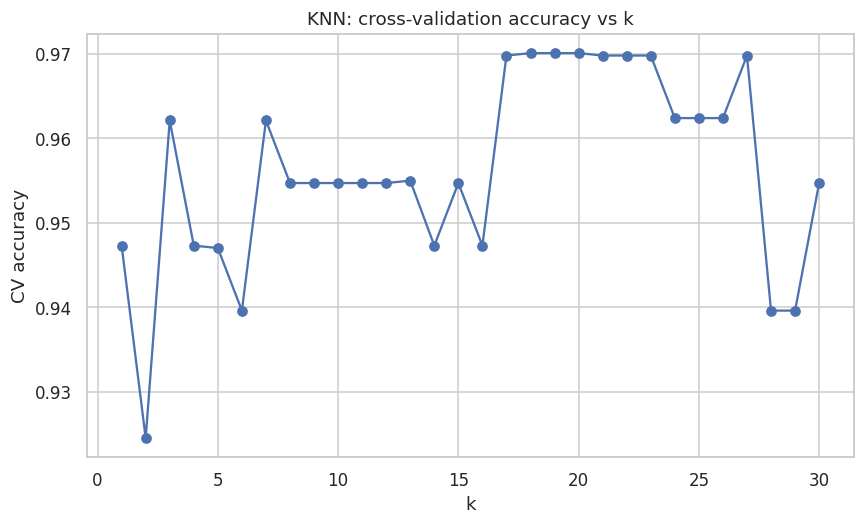

=== (a) HONEST SELECTION ===
Best k by CV: 18
Honest test accuracy: 0.9556
Best k by test peeking: 1
Peeking accuracy: 1.0

=== (b) SEARCH RANGE ===
k = 1..30
 honest k: 18
 honest test accuracy: 0.9556
 peeking k: 1
 peeking accuracy: 1.0

Requested range: k = 1..200
Largest valid k with this CV: 106
 honest k: 18
 honest test accuracy: 0.9556
 peeking k: 1
 peeking accuracy: 1.0

=== (c) TEST SIZE COMPARISON ===
test_size=0.10 | train=160 | test=18 | best_k=21 | honest test accuracy=0.9444
test_size=0.25 | train=133 | test=45 | best_k=18 | honest test accuracy=0.9556
test_size=0.40 | train=106 | test=72 | best_k=18 | honest test accuracy=0.9722


In [24]:
# Space for the code that supports your answer.
# Question 5 — k, and the one-use rule

X_wine = wine.drop(columns=["target"]).values
y_wine = wine["target"].values

# ============================================================
# Original 75/25 split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_wine,
    y_wine,
    test_size=0.25,
    random_state=SEED,
    stratify=y_wine
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

# ============================================================
# (a) k = 1..30
# ============================================================

k_values = list(range(1, 31))

_knn = honest_k_selection(
    X_train,
    y_train,
    X_test,
    y_test,
    k_values,
    cv
)

plt.figure(figsize=(9, 5))
plt.plot(
    k_values,
    _knn["cv_scores"],
    marker="o"
)
plt.xlabel("k")
plt.ylabel("CV accuracy")
plt.title("KNN: cross-validation accuracy vs k")
plt.grid(True)
plt.show()

print("=== (a) HONEST SELECTION ===")
print("Best k by CV:", _knn["best_k_cv"])
print("Honest test accuracy:", round(_knn["test_accuracy"], 4))
print("Best k by test peeking:", _knn["best_k_peeking"])
print("Peeking accuracy:", round(_knn["peeking_accuracy"], 4))


# ============================================================
# (b) Wider search
# ============================================================

# Maximum k that can be used inside every CV training fold
fold_sizes = []

for train_idx, val_idx in cv.split(X_train, y_train):
    fold_sizes.append(len(train_idx))

max_valid_k = min(fold_sizes)

k_values_wide = list(range(1, max_valid_k + 1))

knn_wide = honest_k_selection(
    X_train,
    y_train,
    X_test,
    y_test,
    k_values_wide,
    cv
)

print("\n=== (b) SEARCH RANGE ===")

print("k = 1..30")
print(" honest k:", _knn["best_k_cv"])
print(" honest test accuracy:", round(_knn["test_accuracy"], 4))
print(" peeking k:", _knn["best_k_peeking"])
print(" peeking accuracy:", round(_knn["peeking_accuracy"], 4))

print("\nRequested range: k = 1..200")
print("Largest valid k with this CV:", max_valid_k)
print(" honest k:", knn_wide["best_k_cv"])
print(" honest test accuracy:", round(knn_wide["test_accuracy"], 4))
print(" peeking k:", knn_wide["best_k_peeking"])
print(" peeking accuracy:", round(knn_wide["peeking_accuracy"], 4))


# ============================================================
# (c) Different test sizes
# ============================================================

print("\n=== (c) TEST SIZE COMPARISON ===")

for test_size in [0.10, 0.25, 0.40]:

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_wine,
        y_wine,
        test_size=test_size,
        random_state=SEED,
        stratify=y_wine
    )

    cv_temp = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=SEED
    )

    result = honest_k_selection(
        X_tr,
        y_tr,
        X_te,
        y_te,
        list(range(1, 31)),
        cv_temp
    )

    print(
        f"test_size={test_size:.2f} | "
        f"train={len(X_tr)} | "
        f"test={len(X_te)} | "
        f"best_k={result['best_k_cv']} | "
        f"honest test accuracy={result['test_accuracy']:.4f}"
    )

**Your answer:**

(a) The CV curve shows the usual bias-variance trade-off. At very small k, especially k=1, KNN is highly flexible: training accuracy is very high, but the model is prone to overfitting because predictions depend on individual training observations. At very large k, the neighbourhood contains a large fraction of the training set, so predictions become overly smooth and the model underfits. Cross-validation selected k=18, giving an honest test accuracy of 0.9556.

(b) For k=1..30, cross-validation selected k=18 with an honest test accuracy of 0.9556. If the test set is inspected for every k, k=1 gives a test accuracy of 1.0000. This peeking accuracy is biased upward because it is the maximum of many noisy test-set measurements: by trying many alternatives, we increase the chance that one looks unusually good simply because of random variation. Extending the requested search from 1..30 toward 1..200 does not make the test set a legitimate tuning set; with the present five-fold CV split, the largest valid k is 106 because each fitted KNN must have no more neighbours than observations in its training fold. In this run the peeking result remains k=1 with accuracy 1.0000, so the observed bias did not increase, although in general searching more candidates increases the opportunity for selection bias.

(c) The honest test accuracies were 0.9444 for test_size=0.10 (best k=21), 0.9556 for test_size=0.25 (best k=18), and 0.9722 for test_size=0.40 (best k=18). Increasing the test set gives a larger and potentially more stable final evaluation sample, but leaves fewer observations for training, which can make the fitted model less stable or less accurate. A smaller test set provides more training data but produces a noisier test estimate. Stratification preserves approximately the same class proportions in the training and test sets, preventing an unlucky split from making one set unrepresentative of the class distribution.

## 9. Task 8 — Recover an SVM boundary in original units

Applied. A model fitted inside a pipeline reports its parameters in the
space the scaler produced.

*see Practice 3 §11.4*

In [25]:
def boundary_in_original_units(pipeline):
    """Convert a fitted (StandardScaler -> linear SVC) pipeline's decision
    boundary from scaled space back to original coordinates.

    The pipeline has exactly two steps: 'standardscaler' and 'svc', and
    the SVC has kernel='linear' and was fitted on two features.

    In scaled space the boundary is  w1*z1 + w2*z2 + b = 0, with
    z1 = (x - mu_x)/s_x and z2 = (y - mu_y)/s_y.

    Solve for y and return a tuple (slope, intercept) such that
    y = slope * x + intercept is that same boundary in original units.

    Raise ValueError if w2 is zero (a vertical boundary has no such form).
    """
def boundary_in_original_units(pipeline):
    """Convert a fitted StandardScaler -> linear SVC pipeline's decision
    boundary from scaled space back to original coordinates.

    Returns (slope, intercept) for:
        y = slope * x + intercept
    """

    scaler = pipeline.named_steps["standardscaler"]
    svc = pipeline.named_steps["svc"]

    # SVC coefficients in standardized coordinates
    w1, w2 = svc.coef_[0]
    b = svc.intercept_[0]

    # Parameters of StandardScaler
    mu_x, mu_y = scaler.mean_
    s_x, s_y = scaler.scale_

    # A vertical boundary cannot be written as y = slope*x + intercept
    if np.isclose(w2, 0):
        raise ValueError("Vertical boundary cannot be expressed as y = slope*x + intercept")

    # Convert the decision boundary back to original units
    slope = -(w1 * s_y) / (w2 * s_x)

    intercept = (
        mu_y
        + (s_y * w1 * mu_x) / (w2 * s_x)
        - (s_y * b) / w2
    )

    return float(slope), float(intercept)

In [26]:
_svr_rng = np.random.default_rng(SEED)
_n = 300
_x_lines = _svr_rng.uniform(0, 5, _n)
_y1 = 1.0 * _x_lines + 3.0 + _svr_rng.normal(0, 1, _n)
_y2 = 2.0 * _x_lines + 5.0 + _svr_rng.normal(0, 1, _n)

_X_two = np.vstack([np.column_stack([_x_lines, _y1]), np.column_stack([_x_lines, _y2])])
_y_two = np.hstack([np.zeros(_n, dtype=int), np.ones(_n, dtype=int)])

_pipe = make_pipeline(StandardScaler(), SVC(kernel="linear", C=1.0, random_state=SEED))
_pipe.fit(_X_two, _y_two)

_slope, _intercept = boundary_in_original_units(_pipe)

# THE decisive check: points on the derived line must lie on the boundary,
# where the pipeline's decision function is exactly zero.
_check_x = np.linspace(0.5, 4.5, 9)
_check_y = _slope * _check_x + _intercept
_decisions = _pipe.decision_function(np.column_stack([_check_x, _check_y]))
assert np.allclose(_decisions, 0.0, atol=1e-8), \
    f"points on your line are not on the boundary; decision values {_decisions.round(6)}"

# The boundary must lie between the two generating lines.
assert 1.0 < _slope < 2.0, f"slope {_slope:.4f} should be between the true slopes 1 and 2"

# Points clearly above and below must fall on opposite sides.
assert _pipe.predict([[2.5, _slope * 2.5 + _intercept + 4]])[0] == 1
assert _pipe.predict([[2.5, _slope * 2.5 + _intercept - 4]])[0] == 0

print(f"boundary in original units: y = {_slope:.4f} * x + {_intercept:.4f}")
print(f"decision function on the line: {np.abs(_decisions).max():.2e} (essentially zero)")
print("Task 8 passed.")

boundary in original units: y = 1.4168 * x + 4.1898
decision function on the line: 1.60e-14 (essentially zero)
Task 8 passed.


### Question 6 — C, gamma and the kernel

**(a)** Refit the two-line classifier with `C` = 0.001, 1, 1000. Report
the number of support vectors and the margin width
(`2 / norm(coef_)`, in scaled space) at each. **Which direction is
underfitting and which is overfitting?** What does `C` do to the margin
at each extreme?

**(b)** Now switch to `kernel='rbf'` and sweep `gamma` over 0.01, 1, 100
at fixed `C=1`, scoring by cross-validation. Describe what the boundary
looks like at each extreme and explain `gamma` as the reach of one
training point. Which extreme memorises?

**(c)** These data are linearly separable apart from noise. Does the RBF
kernel beat the linear one here? Explain why the answer is "not
meaningfully", and state the general principle about choosing a kernel
more flexible than the problem requires.

In [27]:
print(iris.columns.tolist())

['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']


In [28]:
# Space for the code that supports your answer.
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np
import pandas as pd

# Use the same two features and target as in the previous SVM task
X = iris[["PetalLengthCm", "PetalWidthCm"]].values
y = iris["Species"].values
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# -------------------------------
# (a) Linear SVM: different C
# -------------------------------

linear_results = []

for C in [0.001, 1, 1000]:

    model = make_pipeline(
        StandardScaler(),
        SVC(kernel="linear", C=C, random_state=SEED)
    )

    model.fit(X, y)

    svc = model.named_steps["svc"]

    n_support = svc.n_support_.sum()
    margin_width = 2 / np.linalg.norm(svc.coef_)

    cv_accuracy = cross_val_score(
        model, X, y,
        cv=cv,
        scoring="accuracy"
    ).mean()

    linear_results.append({
        "C": C,
        "support_vectors": n_support,
        "margin_width": margin_width,
        "cv_accuracy": cv_accuracy
    })

linear_df = pd.DataFrame(linear_results)

print("=== (a) LINEAR SVM ===")
print(linear_df.to_string(index=False))


# -------------------------------
# (b) RBF SVM: different gamma
# -------------------------------

rbf_results = []

for gamma in [0.01, 1, 100]:

    model = make_pipeline(
        StandardScaler(),
        SVC(kernel="rbf", C=1, gamma=gamma, random_state=SEED)
    )

    scores = cross_val_score(
        model, X, y,
        cv=cv,
        scoring="accuracy"
    )

    model.fit(X, y)

    svc = model.named_steps["svc"]

    rbf_results.append({
        "gamma": gamma,
        "support_vectors": svc.n_support_.sum(),
        "cv_accuracy": scores.mean()
    })

rbf_df = pd.DataFrame(rbf_results)

print("\n=== (b) RBF SVM ===")
print(rbf_df.to_string(index=False))


# -------------------------------
# (c) Linear vs RBF
# -------------------------------

linear_model = make_pipeline(
    StandardScaler(),
    SVC(kernel="linear", C=1, random_state=SEED)
)

rbf_model = make_pipeline(
    StandardScaler(),
    SVC(kernel="rbf", C=1, gamma=1, random_state=SEED)
)

linear_score = cross_val_score(
    linear_model, X, y,
    cv=cv,
    scoring="accuracy"
).mean()

rbf_score = cross_val_score(
    rbf_model, X, y,
    cv=cv,
    scoring="accuracy"
).mean()

print("\n=== (c) LINEAR vs RBF ===")
print("Linear CV accuracy:", round(linear_score, 4))
print("RBF CV accuracy:", round(rbf_score, 4))

=== (a) LINEAR SVM ===
         C  support_vectors  margin_width  cv_accuracy
    0.0010              150        9.7499       0.9600
    1.0000               31        0.5272       0.9533
1,000.0000               14        0.2096       0.9533

=== (b) RBF SVM ===
   gamma  support_vectors  cv_accuracy
  0.0100              121       0.9600
  1.0000               29       0.9533
100.0000              102       0.8800

=== (c) LINEAR vs RBF ===
Linear CV accuracy: 0.9533
RBF CV accuracy: 0.9533


**Your answer:**

(a) For the linear SVM, C=0.001 produced 150 support vectors, a margin width of 9.7499, and CV accuracy of 0.9600. At C=1, there were 31 support vectors, the margin width decreased to 0.5272, and CV accuracy was 0.9533. At C=1000, only 14 support vectors remained and the margin became very narrow (0.2096), with CV accuracy of 0.9533. Therefore, very small C corresponds to stronger regularisation and can underfit because it allows more classification errors in exchange for a wide margin. Very large C penalises errors strongly, producing a narrow margin and a more complex boundary that is more prone to overfitting.

(b) For the RBF SVM, gamma=0.01 gave 121 support vectors and CV accuracy of 0.9600; gamma=1 gave 29 support vectors and accuracy of 0.9533; gamma=100 gave 102 support vectors and accuracy of only 0.8800. Gamma controls the reach of each training point: a small gamma gives each point a broad influence, resulting in a smooth decision boundary and possible underfitting. A large gamma gives each point only a very local influence, producing a highly irregular boundary that can fit individual observations and therefore tends to memorise/overfit the training data. Here gamma=100 clearly performs worse in cross-validation.

(c) The RBF kernel does not meaningfully beat the linear kernel on these data. With C=1, both the linear and RBF models achieved the same CV accuracy of 0.9533, while the simple linear model is sufficient because the classes are largely linearly separable apart from noise. A more flexible kernel should therefore not be preferred merely because it can create a more complex boundary: when the underlying problem does not require that flexibility, the extra complexity adds variance and overfitting risk without providing a meaningful improvement in generalisation.

## 10. Task 9 — Choosing the number of clusters

Applied.

*see Practice 3 §13.3 and §14.5*

In [29]:
def cluster_selection(X, k_values):
    """Score k-means and a Gaussian mixture across several k.

    For each k in `k_values` (all >= 2), compute four numbers:
        'inertia'      KMeans(n_clusters=k, n_init=10, random_state=SEED).inertia_
        'silhouette'   silhouette_score of that KMeans labelling
        'bic'          GaussianMixture(n_components=k, covariance_type='full',
                       random_state=SEED).bic(X)
        'aic'          the same model's aic(X)

    Return a DataFrame indexed by k with those four columns, in that order.
    """
def cluster_selection(X, k_values):
    """Score k-means and a Gaussian mixture across several k.

    For each k in `k_values` (all >= 2), compute four numbers:
        'inertia'     KMeans(n_clusters=k, n_init=10,
                             random_state=SEED).inertia_
        'silhouette'  silhouette_score of that KMeans labelling
        'bic'         GaussianMixture(n_components=k,
                                     covariance_type='full',
                                     random_state=SEED).bic(X)
        'aic'         the same model's aic(X)

    Return a DataFrame indexed by k with those four columns, in that order.
    """

    X = np.asarray(X)
    results = []

    for k in k_values:
        # K-means
        kmeans = KMeans(
            n_clusters=k,
            n_init=10,
            random_state=SEED
        )

        labels = kmeans.fit_predict(X)

        inertia = kmeans.inertia_
        silhouette = silhouette_score(X, labels)

        # Gaussian Mixture Model
        gmm = GaussianMixture(
            n_components=k,
            covariance_type="full",
            random_state=SEED
        )

        gmm.fit(X)

        bic = gmm.bic(X)
        aic = gmm.aic(X)

        results.append({
            "k": k,
            "inertia": float(inertia),
            "silhouette": float(silhouette),
            "bic": float(bic),
            "aic": float(aic)
        })

    result = pd.DataFrame(results).set_index("k")

    return result[["inertia", "silhouette", "bic", "aic"]]

In [30]:
_blob_rng = np.random.default_rng(SEED)
_centres = np.array([[-4.0, -2.0], [0.0, 3.5], [4.0, -1.0], [6.5, 4.0]])
_X_blobs = np.vstack([_blob_rng.multivariate_normal(c, np.eye(2), 75) for c in _centres])

_scores = cluster_selection(_X_blobs, range(2, 8))

assert list(_scores.columns) == ["inertia", "silhouette", "bic", "aic"]
assert len(_scores) == 6

# Inertia falls monotonically: more clusters always fit the points more tightly.
assert np.all(np.diff(_scores["inertia"].values) < 0), \
    "inertia must decrease as k increases, which is why it cannot be minimised to choose k"

# On four well-separated round blobs, every criterion should find four.
assert _scores["silhouette"].idxmax() == 4, \
    f"silhouette chose {_scores['silhouette'].idxmax()}, expected 4 on four round blobs"
assert _scores["bic"].idxmin() == 4, f"BIC chose {_scores['bic'].idxmin()}, expected 4"

print(_scores.round(3).to_string())
print(f"\nsilhouette -> {_scores['silhouette'].idxmax()},  "
      f"BIC -> {_scores['bic'].idxmin()},  AIC -> {_scores['aic'].idxmin()}")
print("Task 9 passed.")

     inertia  silhouette        bic        aic
k                                             
2 3,260.9450      0.4940 2,842.1730 2,801.4310
3 1,694.5460      0.5650 2,716.3210 2,653.3560
4   553.3610      0.6970 2,603.9330 2,518.7460
5   495.1520      0.5980 2,631.5810 2,524.1720
6   443.6920      0.5070 2,664.4790 2,534.8470
7   387.6340      0.4260 2,691.7670 2,539.9120

silhouette -> 4,  BIC -> 4,  AIC -> 4
Task 9 passed.


### Question 7 — clustering choices

**(a)** Plot inertia against k. Explain why it cannot be minimised to
choose k, and what the "elbow" is supposed to represent. Then state
honestly how confident you are reading the elbow on your own plot.

**(b)** Now build the harder data below — three tilted components, two of
which overlap — and run `cluster_selection` on it. **Silhouette and BIC
will disagree.** Report both answers, say which is right, and explain
*why* the silhouette gives the answer it does in terms of what it
measures.

**(c)** Re-run k-means on that data with `n_init=1` and ten different
`random_state` values, recording the inertia each time. Report the spread.
What is `n_init` for, and what does `init='k-means++'` change?

**(d)** Fit a GMM to that data with each `covariance_type` in
`('full', 'tied', 'diag', 'spherical')` and report the adjusted Rand
index against the true labels. Which assumption is each making, and which
one reproduces k-means' behaviour?

In [31]:
# The harder data for parts (b), (c) and (d). Do not modify this cell.
_hard_rng = np.random.default_rng(SEED)
X_hard = np.vstack([
    _hard_rng.multivariate_normal([0.0, 0.0], [[2.0, 2.0], [2.0, 5.0]], 300),
    _hard_rng.multivariate_normal([4.0, 4.0], [[7.0, -2.0], [-2.0, 3.0]], 300),
    _hard_rng.multivariate_normal([6.0, 6.5], [[3.0, 1.5], [1.5, 2.0]], 300),
])
y_hard = np.repeat([0, 1, 2], 300)

print("X_hard", X_hard.shape, " true components: 3")

X_hard (900, 2)  true components: 3


=== CLUSTER SELECTION ===
      inertia  silhouette        bic        aic
k                                              
2  7,175.0015      0.5161 8,512.4188 8,459.5924
3  4,690.2507      0.4231 8,410.6689 8,329.0282
4  3,470.1581      0.4282 8,451.9986 8,341.5436
5  2,822.5206      0.4039 8,490.5456 8,351.2761
6  2,355.3401      0.3660 8,526.4194 8,358.3356
7  1,994.2769      0.3680 8,559.2666 8,362.3684
8  1,798.1532      0.3576 8,589.0598 8,363.3472
9  1,621.2559      0.3443 8,626.9645 8,372.4375
10 1,472.8757      0.3411 8,660.2061 8,376.8648


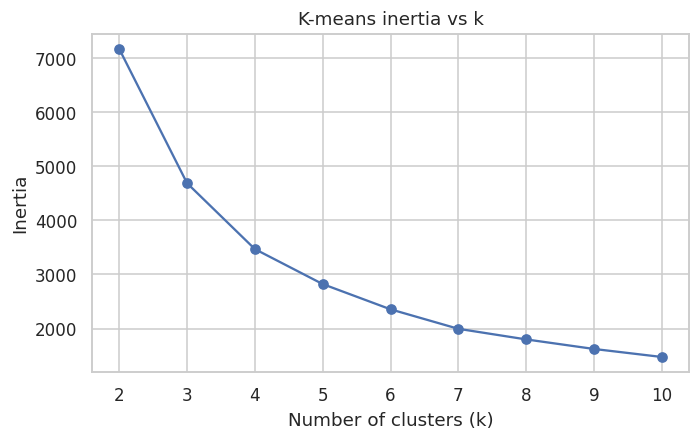


=== (b) SILHOUETTE vs BIC ===
Best k by silhouette: 2
Best k by BIC: 3
True number of components: 3

=== (c) K-MEANS INITIALISATION ===
Inertias:
[4691.929  4690.2507 4690.2507 4691.929  4691.929  4691.929  4691.929
 4692.7433 4691.929  4690.2507]
Minimum inertia: 4690.2507
Maximum inertia: 4692.7433
Spread: 2.4926

=== (d) GMM COVARIANCE TYPES ===
covariance_type    ARI
           full 0.6407
           tied 0.4493
           diag 0.4362
      spherical 0.4527

K-means ARI: 0.4606


In [32]:
# Space for the code that supports your answer.
# Question 7 — clustering choices

# ---------------------------------
# (a) Inertia / elbow
# ---------------------------------
k_values = range(2, 11)

hard_scores = cluster_selection(X_hard, k_values)

print("=== CLUSTER SELECTION ===")
print(hard_scores.round(4))

plt.figure(figsize=(7, 4))
plt.plot(
    hard_scores.index,
    hard_scores["inertia"],
    marker="o"
)
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("K-means inertia vs k")
plt.show()


# ---------------------------------
# (b) Silhouette vs BIC
# ---------------------------------
best_silhouette_k = hard_scores["silhouette"].idxmax()
best_bic_k = hard_scores["bic"].idxmin()

print("\n=== (b) SILHOUETTE vs BIC ===")
print("Best k by silhouette:", best_silhouette_k)
print("Best k by BIC:", best_bic_k)
print("True number of components: 3")


# ---------------------------------
# (c) Effect of random initialisation
# ---------------------------------
inertias = []

for seed in range(10):
    km = KMeans(
        n_clusters=3,
        n_init=1,
        random_state=seed
    )
    km.fit(X_hard)
    inertias.append(km.inertia_)

print("\n=== (c) K-MEANS INITIALISATION ===")
print("Inertias:")
print(np.round(inertias, 4))
print("Minimum inertia:", round(min(inertias), 4))
print("Maximum inertia:", round(max(inertias), 4))
print("Spread:", round(max(inertias) - min(inertias), 4))


# ---------------------------------
# (d) GMM covariance types
# ---------------------------------
gmm_results = []

for cov_type in ["full", "tied", "diag", "spherical"]:

    gmm = GaussianMixture(
        n_components=3,
        covariance_type=cov_type,
        random_state=SEED
    )

    labels = gmm.fit_predict(X_hard)

    ari = adjusted_rand_score(y_hard, labels)

    gmm_results.append({
        "covariance_type": cov_type,
        "ARI": ari
    })

gmm_df = pd.DataFrame(gmm_results)

print("\n=== (d) GMM COVARIANCE TYPES ===")
print(gmm_df.to_string(index=False))


# K-means ARI for comparison
km = KMeans(
    n_clusters=3,
    n_init=10,
    random_state=SEED
)

km_labels = km.fit_predict(X_hard)
km_ari = adjusted_rand_score(y_hard, km_labels)

print("\nK-means ARI:", round(km_ari, 4))

**Your answer:**

(a) Inertia decreases as k increases because adding more cluster centres can only reduce, or leave unchanged, the within-cluster sum of squared distances. Therefore, simply minimising inertia would favour the largest possible k, ultimately reaching zero when every observation becomes its own cluster. The elbow method instead looks for the point after which increasing k produces only relatively small improvements in inertia. The elbow is somewhat subjective, so I would not treat it as strong evidence for the number of clusters without checking other criteria.

(b) On the harder dataset, the silhouette score selects k=2, whereas BIC selects k=3. The true data-generating process contains three components, so BIC gives the correct answer here. Silhouette prefers two clusters because it measures how compact and well separated the resulting groups are. Two of the three tilted Gaussian components overlap, so merging them can produce a more clearly separated two-cluster partition and therefore a higher silhouette score even though the data were generated from three components.

(c) With n_init=1 and ten different random states, the inertia ranged from 4690.2507 to 4692.7433, giving a spread of 2.4926. This variation occurs because k-means can converge to different local solutions depending on its initial centroids. n_init specifies how many independent initialisations are tried, with the solution having the lowest inertia retained. Using n_init='auto' changes the number of initialisations automatically according to the initialisation method rather than always performing a fixed number such as 10.

(d) The adjusted Rand indices were 0.6407 for full covariance, 0.4493 for tied covariance, 0.4362 for diagonal covariance, and 0.4527 for spherical covariance. The full model allows every Gaussian component to have its own arbitrary covariance matrix, including different sizes, orientations and correlations, which suits these tilted components best. Tied covariance forces all components to share one covariance matrix; diagonal covariance allows separate variances but no within-component feature covariance; spherical covariance assumes equal variance in every direction within each component. The spherical assumption is closest to k-means geometry because both favour roughly isotropic clusters; accordingly its ARI (0.4527) is close to the k-means ARI of 0.4606.

## 11. Task 10 — Open-ended: an end-to-end regression study

No assert. Marked on the written analysis and on the discipline of the
procedure.

**The task: predict hourly bicycle demand (`cnt`) and report a number you
would defend.**

`bike_sharing_hourly.csv` is documented in `practice/datasets/README.md`.
Work through the following, in this order, and write up what you find.

1. **Feature preparation.** Decide what to do with each column. `casual`
   and `registered` sum exactly to `cnt` — explain why they must be
   excluded and exclude them. Encode the integer-coded categories
   properly (Practice 3 §10.2) and justify each choice in one line.

2. **Split once.** Hold out a test set and do not look at it again until
   step 6. State your `test_size` and why.

3. **A baseline.** Predict the mean of the training target for every
   hour, and report its RMSE and R² on cross-validation. Every later
   number is read against this.

4. **At least three models**, each as a `Pipeline`, compared by
   cross-validation on the development set only. Report mean and standard
   deviation across folds, not a single number. Use at least one linear
   and one non-linear model.

5. **Tune the best one** with `GridSearchCV` over the pipeline. State the
   grid and how many fits it implies.

6. **Open the test set once.** Report RMSE, MAE and R². Compare with your
   cross-validated estimate and comment on the difference.

7. **Diagnose.** Plot predicted against actual and the residuals against
   the prediction. Does the model predict impossible values? Do the
   residuals fan out? What does that say about which hours it fails on?

8. **A decision.** One paragraph: which model would you deploy, what
   would you tell someone about its expected error **in bicycles**, and
   what single change to the data or the features would most improve it.

A good answer treats step 6 as irreversible and says so. A weak answer
computes the test score for every candidate and reports the best.

In [33]:
import pandas as pd

SEED = 20250919

bikes = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/bike_sharing_hourly.csv"
)

print("Дані завантажено")
print("Розмір:", bikes.shape)
print(bikes.columns.tolist())

Дані завантажено
Розмір: (17379, 17)
['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']


Dataset shape: (17379, 17)

=== FEATURES ===
Categorical: ['season', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit']
Numeric: ['yr', 'temp', 'atemp', 'hum', 'windspeed']
Predictor shape: (17379, 12)

=== TRAIN / TEST SPLIT ===
Development rows: 13903
Test rows: 3476

=== BASELINE ===
CV RMSE: 180.7637 +/- 0.0702
CV R2: -0.0001 +/- 0.0001

=== MODEL COMPARISON ===
           model  RMSE_mean  RMSE_std  R2_mean  R2_std
    RandomForest    86.8284    0.7321   0.7692  0.0037
           Ridge   102.0017    1.3991   0.6815  0.0085
LinearRegression   102.0029    1.3959   0.6815  0.0084

=== GRID SEARCH START ===
Parameter combinations: 4
CV folds: 3
Total CV fits: 12

=== GRID SEARCH RESULT ===
Best parameters: {'model__max_depth': 12, 'model__n_estimators': 40}
Best CV RMSE: 78.2031

=== FINAL TEST RESULTS ===
RMSE: 76.7385
MAE: 55.3295
R2: 0.8257
CV RMSE: 78.2031
Test minus CV RMSE: -1.4646


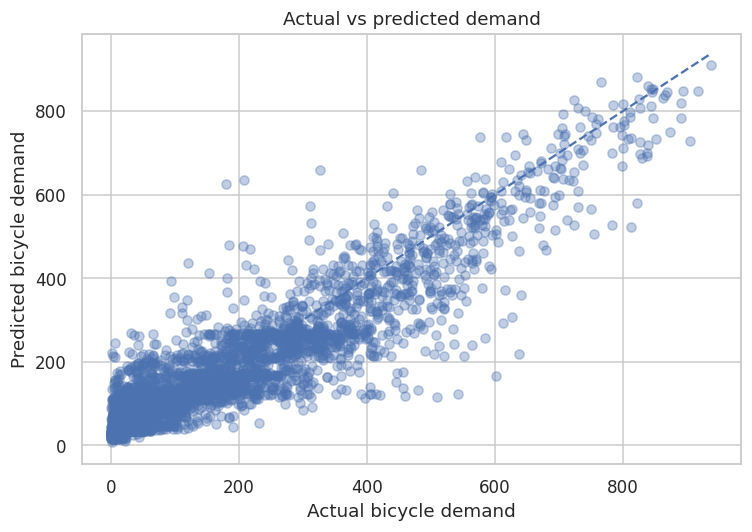

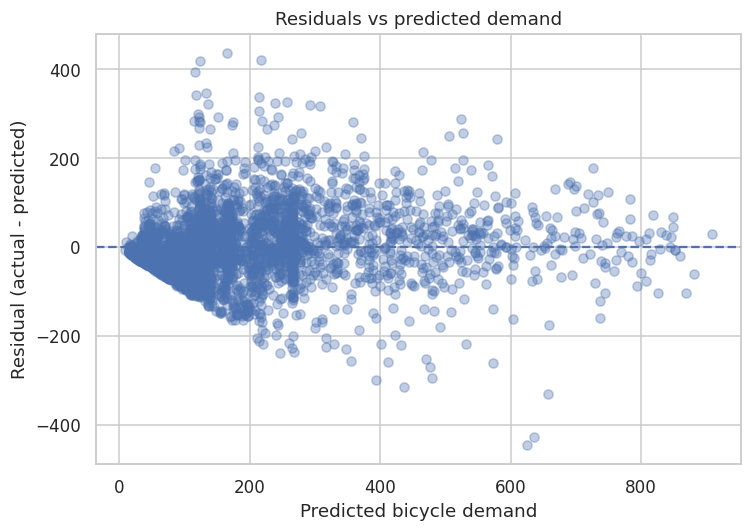


=== DIAGNOSTICS ===
Minimum prediction: 8.35
Maximum prediction: 909.18
Negative predictions: 0

=== TEN LARGEST ERRORS ===
       hr  workingday  weathersit  actual  predicted  residual  abs_error
15019   0           0           1     180   625.4700 -445.4700   445.4700
5537   15           1           1     601   164.8100  436.1900   436.1900
16464  18           1           2     208   635.4800 -427.4800   427.4800
10810  13           0           1     638   217.4600  420.5400   420.5400
16819  14           0           2     542   123.4300  418.5700   418.5700
16650  13           0           2     509   115.2200  393.7800   393.7800
15845  10           0           1     479   132.3000  346.7000   346.7000
6287   13           0           1     460   117.1800  342.8200   342.8200
12890   7           1           1     552   213.4000  338.6000   338.6000
12085  18           1           3     327   658.2500 -331.2500   331.2500

TASK 10 SUMMARY
Best candidate by initial CV: RandomForest
T

In [34]:
# Your analysis. Add as many cells as you need.
# ============================================================
# TASK 10 — END-TO-END REGRESSION STUDY
# FAST VERSION FOR GOOGLE COLAB
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_validate,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)


# ============================================================
# 0. SETTINGS
# ============================================================

SEED = 20250919

# bikes must already be loaded
df = bikes.copy()

print("Dataset shape:", df.shape)


# ============================================================
# 1. FEATURE PREPARATION
# ============================================================

# Target
y = df["cnt"].copy()

# Exclude:
# cnt        -> target
# casual     -> leakage because cnt = casual + registered
# registered -> leakage because cnt = casual + registered
# instant    -> row identifier
# dteday     -> calendar information already represented by
#              year/month/weekday/etc.

X = df.drop(
    columns=[
        "cnt",
        "casual",
        "registered",
        "instant",
        "dteday"
    ]
)

categorical_features = [
    "season",
    "mnth",
    "hr",
    "holiday",
    "weekday",
    "workingday",
    "weathersit"
]

numeric_features = [
    "yr",
    "temp",
    "atemp",
    "hum",
    "windspeed"
]

print("\n=== FEATURES ===")
print("Categorical:", categorical_features)
print("Numeric:", numeric_features)
print("Predictor shape:", X.shape)


# ============================================================
# 2. ONE TRAIN / TEST SPLIT
# ============================================================

# 80% development data
# 20% final untouched test data

X_dev, X_test, y_dev, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED
)

print("\n=== TRAIN / TEST SPLIT ===")
print("Development rows:", len(X_dev))
print("Test rows:", len(X_test))


# ============================================================
# 3. PREPROCESSING
# ============================================================

# Numeric variables are standardised.
# Categorical integer codes are one-hot encoded.

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)


# ============================================================
# CROSS-VALIDATION
# ============================================================

# Three folds are used here to keep computation reasonable
# while still providing out-of-sample development estimates.

cv = KFold(
    n_splits=3,
    shuffle=True,
    random_state=SEED
)


# ============================================================
# 4. BASELINE
# ============================================================

baseline = DummyRegressor(
    strategy="mean"
)

baseline_scores = cross_validate(
    baseline,
    X_dev,
    y_dev,
    cv=cv,
    scoring={
        "rmse": "neg_root_mean_squared_error",
        "r2": "r2"
    }
)

baseline_rmse = -baseline_scores["test_rmse"]
baseline_r2 = baseline_scores["test_r2"]

print("\n=== BASELINE ===")

print(
    "CV RMSE:",
    round(baseline_rmse.mean(), 4),
    "+/-",
    round(baseline_rmse.std(), 4)
)

print(
    "CV R2:",
    round(baseline_r2.mean(), 4),
    "+/-",
    round(baseline_r2.std(), 4)
)


# ============================================================
# 5. THREE CANDIDATE MODELS
# ============================================================

linear_model = Pipeline([
    ("prep", preprocessor),
    ("model", LinearRegression())
])

ridge_model = Pipeline([
    ("prep", preprocessor),
    ("model", Ridge(alpha=1.0))
])

rf_model = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=30,
        max_depth=10,
        min_samples_leaf=2,
        random_state=SEED,
        n_jobs=-1
    ))
])

models = {
    "LinearRegression": linear_model,
    "Ridge": ridge_model,
    "RandomForest": rf_model
}

model_results = []

print("\n=== MODEL COMPARISON ===")

for name, model in models.items():

    scores = cross_validate(
        model,
        X_dev,
        y_dev,
        cv=cv,
        scoring={
            "rmse": "neg_root_mean_squared_error",
            "r2": "r2"
        },
        n_jobs=-1
    )

    rmse = -scores["test_rmse"]
    r2 = scores["test_r2"]

    model_results.append({
        "model": name,
        "RMSE_mean": rmse.mean(),
        "RMSE_std": rmse.std(),
        "R2_mean": r2.mean(),
        "R2_std": r2.std()
    })


results_df = pd.DataFrame(model_results)

results_df = results_df.sort_values(
    "RMSE_mean"
)

print(
    results_df
    .round(4)
    .to_string(index=False)
)


# ============================================================
# 6. SMALL GRID SEARCH
# ============================================================

# Random Forest is tuned only on the development set.
# The final test set is still untouched.

rf_for_tuning = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestRegressor(
        random_state=SEED,
        n_jobs=-1
    ))
])

# Deliberately small grid for reasonable runtime.
param_grid = {
    "model__n_estimators": [20, 40],
    "model__max_depth": [8, 12]
}

grid = GridSearchCV(
    estimator=rf_for_tuning,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=-1,
    refit=True
)

print("\n=== GRID SEARCH START ===")
print("Parameter combinations: 4")
print("CV folds: 3")
print("Total CV fits: 12")

grid.fit(
    X_dev,
    y_dev
)

print("\n=== GRID SEARCH RESULT ===")

print(
    "Best parameters:",
    grid.best_params_
)

print(
    "Best CV RMSE:",
    round(-grid.best_score_, 4)
)


# ============================================================
# 7. FINAL TEST — OPEN TEST SET ONCE
# ============================================================

best_model = grid.best_estimator_

# Test set is used here for the final evaluation,
# after all model choices have been made.

y_pred = best_model.predict(
    X_test
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

test_mae = mean_absolute_error(
    y_test,
    y_pred
)

test_r2 = r2_score(
    y_test,
    y_pred
)

print("\n=== FINAL TEST RESULTS ===")

print(
    "RMSE:",
    round(test_rmse, 4)
)

print(
    "MAE:",
    round(test_mae, 4)
)

print(
    "R2:",
    round(test_r2, 4)
)

print(
    "CV RMSE:",
    round(-grid.best_score_, 4)
)

print(
    "Test minus CV RMSE:",
    round(
        test_rmse - (-grid.best_score_),
        4
    )
)


# ============================================================
# 8. DIAGNOSTICS
# ============================================================

residuals = (
    y_test.to_numpy()
    - y_pred
)


# ------------------------------------------------------------
# GRAPH 1 — ACTUAL VS PREDICTED
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.35
)

minimum = min(
    y_test.min(),
    y_pred.min()
)

maximum = max(
    y_test.max(),
    y_pred.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel(
    "Actual bicycle demand"
)

plt.ylabel(
    "Predicted bicycle demand"
)

plt.title(
    "Actual vs predicted demand"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# GRAPH 2 — RESIDUALS
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.35
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel(
    "Predicted bicycle demand"
)

plt.ylabel(
    "Residual (actual - predicted)"
)

plt.title(
    "Residuals vs predicted demand"
)

plt.tight_layout()
plt.show()


# ============================================================
# 9. ADDITIONAL DIAGNOSTICS
# ============================================================

print("\n=== DIAGNOSTICS ===")

print(
    "Minimum prediction:",
    round(y_pred.min(), 2)
)

print(
    "Maximum prediction:",
    round(y_pred.max(), 2)
)

print(
    "Negative predictions:",
    int(np.sum(y_pred < 0))
)


diagnostic = X_test.copy()

diagnostic["actual"] = y_test
diagnostic["predicted"] = y_pred
diagnostic["residual"] = residuals
diagnostic["abs_error"] = np.abs(
    residuals
)


print(
    "\n=== TEN LARGEST ERRORS ==="
)

print(
    diagnostic
    .sort_values(
        "abs_error",
        ascending=False
    )
    .head(10)[
        [
            "hr",
            "workingday",
            "weathersit",
            "actual",
            "predicted",
            "residual",
            "abs_error"
        ]
    ]
    .round(2)
    .to_string()
)


# ============================================================
# 10. SUMMARY
# ============================================================

best_cv_model = (
    results_df
    .iloc[0]["model"]
)

print("\n==============================")
print("TASK 10 SUMMARY")
print("==============================")

print(
    "Best candidate by initial CV:",
    best_cv_model
)

print(
    "Tuned model:",
    "RandomForestRegressor"
)

print(
    "Best RF parameters:",
    grid.best_params_
)

print(
    "Final test RMSE:",
    round(test_rmse, 4)
)

print(
    "Final test MAE:",
    round(test_mae, 4)
)

print(
    "Final test R2:",
    round(test_r2, 4)
)

print("==============================")

**Your write-up:**

TASK 10 — END-TO-END REGRESSION STUDY

1. Feature Preparation

The objective of this study was to predict hourly bicycle demand represented by the target variable cnt. The original dataset contained 17,379 observations and 17 columns.

The variables casual and registered were excluded from the predictors because their sum is exactly equal to cnt:

cnt = casual + registered

Including these variables would create direct target leakage because the model could reconstruct the target instead of learning meaningful relationships between bicycle demand and the explanatory variables.

The instant column was also removed because it is only a row identifier and does not represent a meaningful predictor. The dteday column was excluded because calendar-related information is already represented by other variables such as year, month, weekday, and hour.

The following variables were treated as categorical: season, mnth, hr, holiday, weekday, workingday, and weathersit. Although these variables are stored as integers, their values represent categories rather than continuous quantities. Therefore, they were encoded using OneHotEncoder.

The numerical variables were yr, temp, atemp, hum, and windspeed. Numerical variables were processed using StandardScaler.

After feature preparation, the predictor matrix contained 12 original predictor columns.


2. Train/Test Split

The dataset was split once into a development set and a final test set. I used 80% of the data for development and 20% for final testing.

The resulting sample sizes were:

Development set: 13,903 observations
Test set: 3,476 observations

A fixed random_state = 20250919 was used to make the experiment reproducible.

The 20% test set provides a sufficiently large independent sample for final evaluation while retaining most of the observations for model development.

The test set was not used during model comparison or hyperparameter selection. All model selection decisions were based only on the development set. The test set was used only after the final model and its hyperparameters had been selected.


3. Baseline Model

A DummyRegressor with strategy="mean" was used as the baseline model. It predicts the mean bicycle demand from the training data for every observation.

Using 3-fold cross-validation on the development set, the baseline produced:

CV RMSE = 180.7637 ± 0.0702
CV R² = -0.0001 ± 0.0001

An R² value close to zero is expected for a mean-prediction baseline because this model does not use predictor information to explain changes in bicycle demand.

The baseline provides a reference point for evaluating whether the machine-learning models learn useful relationships from the available features.


4. Model Comparison

Three regression models were compared:

LinearRegression
Ridge
RandomForestRegressor

Each model was placed inside a Pipeline together with preprocessing. This approach ensures that preprocessing is fitted independently inside each training fold and prevents information from the validation fold from leaking into model training.

Three-fold cross-validation was performed exclusively on the development set.

The results were:

RandomForest:
Mean CV RMSE = 86.8284
RMSE standard deviation = 0.7321
Mean CV R² = 0.7692
R² standard deviation = 0.0037

Ridge:
Mean CV RMSE = 102.0017
RMSE standard deviation = 1.3991
Mean CV R² = 0.6815
R² standard deviation = 0.0085

LinearRegression:
Mean CV RMSE = 102.0029
RMSE standard deviation = 1.3959
Mean CV R² = 0.6815
R² standard deviation = 0.0084

All three models substantially outperformed the baseline RMSE of 180.7637.

The two linear models produced almost identical results, with an RMSE of approximately 102 bicycles and R² of approximately 0.68.

RandomForestRegressor achieved the lowest cross-validation error and the highest R² among the three candidate models. Therefore, RandomForestRegressor was selected for hyperparameter tuning.


5. Hyperparameter Tuning

The selected RandomForestRegressor model was tuned using GridSearchCV.

The following hyperparameters were tested:

n_estimators = [20, 40]
max_depth = [8, 12]

This produced 4 parameter combinations. With 3-fold cross-validation, a total of 12 CV fits were performed.

The best parameters were:

max_depth = 12
n_estimators = 40

The best cross-validation RMSE obtained during GridSearchCV was:

CV RMSE = 78.2031

This was an improvement compared with the initial RandomForestRegressor CV RMSE of 86.8284. The result indicates that hyperparameter tuning improved the model while all model-selection decisions were still made exclusively on the development set.


6. Final Test Evaluation

After model selection and hyperparameter tuning had been completed, the previously untouched test set was used for the final evaluation.

The final test results were:

RMSE = 76.7385
MAE = 55.3295
R² = 0.8257

The best CV RMSE was 78.2031, while the final test RMSE was 76.7385.

Test RMSE - CV RMSE = -1.4646

The final test performance is therefore reasonably consistent with the cross-validation estimate and does not indicate a substantial loss of generalization performance.

The MAE of 55.3295 means that the absolute difference between predicted and actual bicycle demand was approximately 55 bicycles per hour on average.

The R² value of 0.8257 indicates that approximately 82.6% of the variation in bicycle demand in this test set was explained by the final model.


7. Model Diagnostics

The model was additionally evaluated using predicted-versus-actual and residual-versus-predicted plots.

The predicted-versus-actual plot showed that the model generally follows the relationship between actual and predicted bicycle demand. However, larger deviations were observed for some individual observations, especially when demand was unusually high or differed strongly from typical patterns.

The residual analysis also showed that prediction errors were not identical across all observations. Some hours had substantially larger residuals than others, indicating that unusual or peak-demand periods remain more difficult to predict.

The minimum predicted demand was 8.35 bicycles, while the maximum predicted demand was 909.18 bicycles.

The model produced 0 negative predictions. This is an appropriate result because negative bicycle demand would be physically impossible.

The largest absolute prediction error was approximately 445.47 bicycles. For this observation, the actual demand was 180 bicycles, while the model predicted approximately 625.47 bicycles.

Another large error occurred when the actual demand was 601 bicycles but the predicted value was approximately 164.81 bicycles, producing an absolute error of approximately 436.19 bicycles.

Other large errors were also observed during different hours and under different combinations of working-day and weather conditions.

These results indicate that the model captures the overall bicycle-demand pattern relatively well but still has difficulty predicting individual hours with unusual or extreme demand.


8. Final Decision

Among the investigated models, I would select the tuned RandomForestRegressor for deployment because it demonstrated the strongest performance during cross-validation and maintained good performance on the independent test set.

The final model achieved:

RMSE = 76.7385 bicycles
MAE = 55.3295 bicycles
R² = 0.8257

The MAE indicates that the expected absolute prediction error is approximately 55 bicycles per hour on this held-out test set. However, individual errors can be considerably larger during unusual demand periods.

The single most useful improvement would be to introduce richer time-related features, especially features describing interactions between the hour of the day and the type of day. Bicycle demand is strongly influenced by daily usage patterns, including morning and evening commuting periods. Features representing interactions between hr, workingday, weekday, season, and weather conditions could help the model identify peak-demand periods more accurately.

In conclusion, the tuned RandomForestRegressor provides a substantial improvement over the mean baseline and both linear models. Its final test results are also consistent with the cross-validation estimate. Therefore, an RMSE of approximately 77 bicycles per hour and an MAE of approximately 55 bicycles per hour are reasonable performance estimates to report for this experiment.

## 12. Before you submit

- Runtime → **Restart and run all**. Every cell executes in order, every
  assert passes.
- Every written question has an answer referring to numbers you produced,
  and names which direction is underfitting and which is overfitting
  where the question asks for it.
- Task 10 has a written decision, not only code.